In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
class CelebAHQDataset(Dataset):
    def __init__(self, root_dir, image_size=128):
        self.root_dir = root_dir
        self.image_size = image_size
        self.image_files = []
        
        for root, dirs, files in os.walk(root_dir):
            for file in files:
                if file.endswith(('.png', '.jpg', '.jpeg')):
                    self.image_files.append(os.path.join(root, file))
        
        print(f'Total images found: {len(self.image_files)}')
        
        self.transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        image = Image.open(img_path).convert('RGB')
        image = self.transform(image)
        return image

In [3]:
dataset_path = '/kaggle/input/datasets/denislukovnikov/celebahq256-images-only/celebahq256_imgs/train'

IMAGE_SIZE = 128
BATCH_SIZE = 16
NUM_WORKERS = 4

dataset = CelebAHQDataset(root_dir=dataset_path, image_size=IMAGE_SIZE)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f'Dataset size: {len(dataset)}')
print(f'Number of batches: {len(dataloader)}')

Total images found: 27000
Dataset size: 27000
Number of batches: 1688


In [35]:
def create_noise_schedule(timesteps=500, beta_start=0.0001, beta_end=0.02):
    betas = torch.linspace(beta_start, beta_end, timesteps) 
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
    return betas, alphas, alphas_cumprod, alphas_cumprod_prev

TIMESTEPS = 500
BETA_START = 0.0001
BETA_END = 0.02

betas, alphas, alphas_cumprod, alphas_cumprod_prev = create_noise_schedule(
    timesteps=TIMESTEPS,
    beta_start=BETA_START,
    beta_end=BETA_END
)

print(f'Noise schedule created with {TIMESTEPS} timesteps')

Noise schedule created with 500 timesteps


In [36]:
def forward_diffusion(x0, t, alphas_cumprod, device):
    noise = torch.randn_like(x0, device=device)
    sqrt_alpha_cumprod_t = torch.sqrt(alphas_cumprod[t])
    sqrt_one_minus_alpha_cumprod_t = torch.sqrt(1.0 - alphas_cumprod[t])
    
    sqrt_alpha_cumprod_t = sqrt_alpha_cumprod_t.view(-1, 1, 1, 1)
    sqrt_one_minus_alpha_cumprod_t = sqrt_one_minus_alpha_cumprod_t.view(-1, 1, 1, 1)
    
    noisy_image = sqrt_alpha_cumprod_t * x0 + sqrt_one_minus_alpha_cumprod_t * noise
    return noisy_image, noise

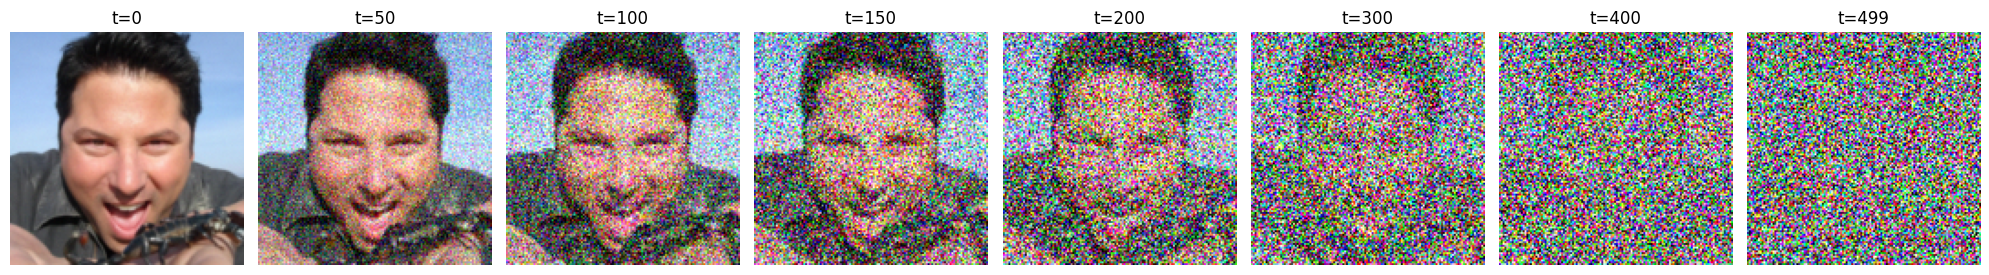

In [37]:
sample_batch = next(iter(dataloader))[:1].to(device)
timesteps_to_show = [0, 50, 100, 150, 200, 300, 400, 499]

fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(20, 3))

for idx, t_val in enumerate(timesteps_to_show):
    t = torch.tensor([t_val], device=device)
    noisy_img, _ = forward_diffusion(sample_batch, t, alphas_cumprod.to(device), device)
    
    img_display = (noisy_img[0].cpu() + 1) / 2
    img_display = torch.clamp(img_display, 0, 1)
    img_np = img_display.permute(1, 2, 0).numpy()
    
    axes[idx].imshow(img_np)
    axes[idx].set_title(f't={t_val}')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [40]:
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Linear(dim * 4, dim)
        )
    
    def forward(self, t):
        half_dim = self.dim // 2
        embeddings = torch.log(torch.tensor(10000.0)) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=t.device) * -embeddings)
        embeddings = t[:, None] * embeddings[None, :]
        embeddings = torch.cat([torch.sin(embeddings), torch.cos(embeddings)], dim=-1)
        embeddings = self.mlp(embeddings)
        return embeddings

In [41]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim, dropout=0.1):
        super().__init__()
        
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.GELU()
        )
        
        self.time_mlp = nn.Sequential(
            nn.GELU(),
            nn.Linear(time_emb_dim, out_channels)
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        
        if in_channels != out_channels:
            self.residual_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.residual_conv = nn.Identity()
    
    def forward(self, x, time_emb):
        residual = self.residual_conv(x)
        h = self.conv1(x)
        time_emb = self.time_mlp(time_emb)[:, :, None, None]
        h = h + time_emb
        h = self.conv2(h)
        return h + residual

In [42]:
class Downsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, kernel_size=3, stride=2, padding=1)
    
    def forward(self, x):
        return self.conv(x)

class Upsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        )
    
    def forward(self, x):
        return self.conv(x)

In [43]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, base_channels=64, 
                 time_emb_dim=128, channel_mults=(1, 2, 4)):
        super().__init__()
        
        self.time_embedding = TimeEmbedding(time_emb_dim)
        self.init_conv = nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1)
        
        channels = [base_channels * mult for mult in channel_mults]
        
        self.encoder_blocks = nn.ModuleList()
        self.downsample_blocks = nn.ModuleList()
        
        prev_channels = base_channels
        for ch in channels:
            self.encoder_blocks.append(nn.ModuleList([
                ResidualBlock(prev_channels, ch, time_emb_dim),
                ResidualBlock(ch, ch, time_emb_dim)
            ]))
            if ch != channels[-1]:
                self.downsample_blocks.append(Downsample(ch))
            else:
                self.downsample_blocks.append(nn.Identity())
            prev_channels = ch
        
        self.bottleneck = nn.ModuleList([
            ResidualBlock(channels[-1], channels[-1], time_emb_dim),
            ResidualBlock(channels[-1], channels[-1], time_emb_dim)
        ])
        
        self.upsample_blocks = nn.ModuleList()
        self.decoder_blocks = nn.ModuleList()
        
        reversed_channels = list(reversed(channels))
        for i, ch in enumerate(reversed_channels):
            if i != 0:
                self.upsample_blocks.append(Upsample(prev_channels))
            else:
                self.upsample_blocks.append(nn.Identity())
            
            self.decoder_blocks.append(nn.ModuleList([
                ResidualBlock(prev_channels + ch, ch, time_emb_dim),
                ResidualBlock(ch, ch, time_emb_dim)
            ]))
            prev_channels = ch
        
        self.final_conv = nn.Sequential(
            nn.GroupNorm(8, base_channels),
            nn.GELU(),
            nn.Conv2d(base_channels, out_channels, kernel_size=3, padding=1)
        )
    
    def forward(self, x, t):
        time_emb = self.time_embedding(t)
        x = self.init_conv(x)
        skip_connections = []
        
        for blocks, downsample in zip(self.encoder_blocks, self.downsample_blocks):
            for block in blocks:
                x = block(x, time_emb)
            skip_connections.append(x)
            x = downsample(x)
        
        for block in self.bottleneck:
            x = block(x, time_emb)
        
        skip_connections = list(reversed(skip_connections))
        
        for upsample, blocks, skip in zip(self.upsample_blocks, self.decoder_blocks, skip_connections):
            x = upsample(x)
            x = torch.cat([x, skip], dim=1)
            for block in blocks:
                x = block(x, time_emb)
        
        x = self.final_conv(x)
        return x

In [44]:
model = UNet(
    in_channels=3,
    out_channels=3,
    base_channels=64,
    time_emb_dim=128,
    channel_mults=(1, 2, 4)
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

Total parameters: 10,745,155


In [45]:
from torch.amp import autocast, GradScaler

EPOCHS = 50
LEARNING_RATE = 2e-4

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scaler = GradScaler('cuda')

best_loss = float('inf')
epoch_losses = []

print(f'Starting training for {EPOCHS} epochs')

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    
    pbar = tqdm(dataloader, desc=f'Epoch {epoch+1}/{EPOCHS}')
    
    for batch in pbar:
        batch = batch.to(device)
        batch_size = batch.shape[0]
        
        t = torch.randint(0, TIMESTEPS, (batch_size,), device=device)
        noisy_images, noise = forward_diffusion(batch, t, alphas_cumprod.to(device), device)
        
        optimizer.zero_grad()
        
        with autocast('cuda'):
            predicted_noise = model(noisy_images, t)
            loss = F.mse_loss(predicted_noise, noise)
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        
        epoch_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = epoch_loss / len(dataloader)
    epoch_losses.append(avg_loss)
    
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), 'best_model.pt')
        print(f'Best model saved at epoch {epoch+1} with loss: {avg_loss:.6f}')
    
    print(f'Epoch {epoch+1} completed - Average loss: {avg_loss:.6f}')

torch.save(model.state_dict(), 'final_model.pt')

Starting training for 50 epochs


Epoch 1/50: 100%|██████████| 1688/1688 [09:07<00:00,  3.08it/s, loss=0.0415]


Best model saved at epoch 1 with loss: 0.047996
Epoch 1 completed - Average loss: 0.047996


Epoch 2/50: 100%|██████████| 1688/1688 [09:06<00:00,  3.09it/s, loss=0.0133]


Best model saved at epoch 2 with loss: 0.023759
Epoch 2 completed - Average loss: 0.023759


...

Epoch 48 completed - Average loss: 0.016904


Epoch 49/50: 100%|██████████| 1688/1688 [09:06<00:00,  3.09it/s, loss=0.0195]


Epoch 49 completed - Average loss: 0.016917


Epoch 50/50: 100%|██████████| 1688/1688 [09:07<00:00,  3.08it/s, loss=0.0098]

Epoch 50 completed - Average loss: 0.016945


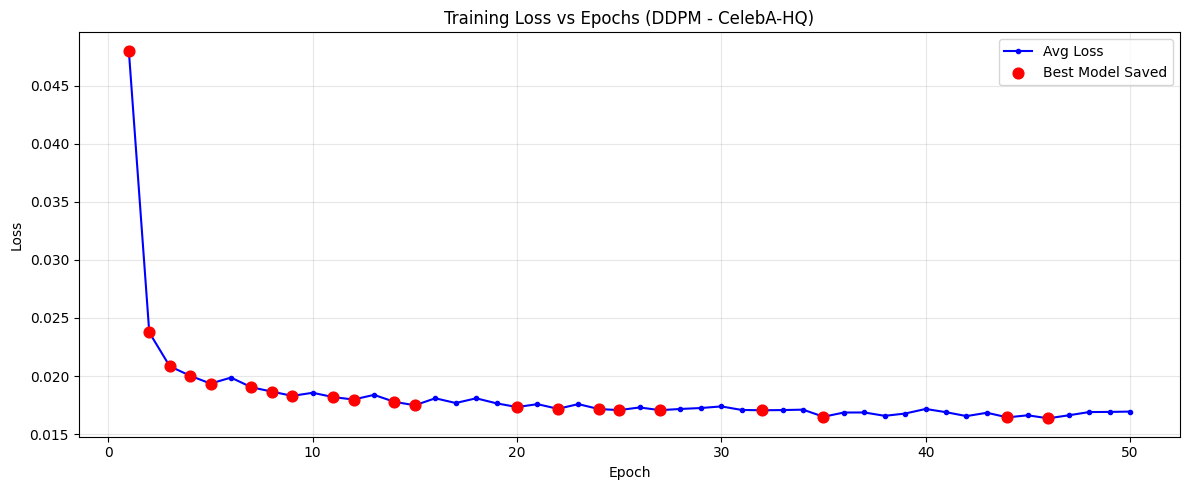

In [46]:
import matplotlib.pyplot as plt

epochs = list(range(1, 51))

avg_losses = [
    0.047996, 0.023759, 0.020850, 0.020029, 0.019356,
    0.019870, 0.019038, 0.018664, 0.018298, 0.018564,
    0.018192, 0.017982, 0.018384, 0.017783, 0.017489,
    0.018090, 0.017683, 0.018088, 0.017654, 0.017335,
    0.017584, 0.017183, 0.017588, 0.017165, 0.017072,
    0.017301, 0.017067, 0.017171, 0.017252, 0.017390,
    0.017085, 0.017058, 0.017076, 0.017111, 0.016501,
    0.016864, 0.016869, 0.016580, 0.016778, 0.017171,
    0.016893, 0.016556, 0.016845, 0.016447, 0.016626,
    0.016364, 0.016625, 0.016904, 0.016917, 0.016945
]

best_epochs = [1, 2, 3, 4, 5, 7, 8, 9, 11, 12, 14, 15, 20, 22, 24, 25, 27, 32, 35, 44, 46]
best_losses = [avg_losses[e-1] for e in best_epochs]

plt.figure(figsize=(12, 5))
plt.plot(epochs, avg_losses, 'b-o', markersize=3, linewidth=1.5, label='Avg Loss')
plt.scatter(best_epochs, best_losses, color='red', zorder=5, s=60, label='Best Model Saved')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss vs Epochs (DDPM - CelebA-HQ)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Model loaded!


Generating: 100%|██████████| 500/500 [00:32<00:00, 15.32it/s]


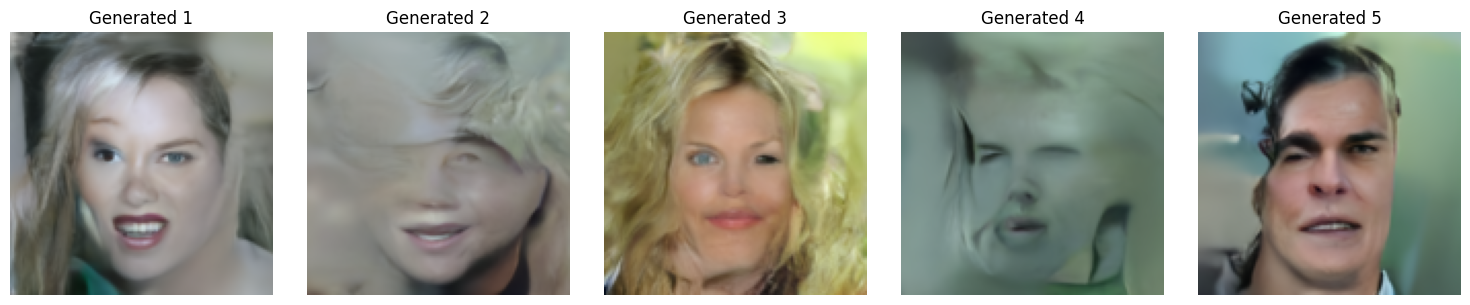

Reconstructing: 100%|██████████| 300/300 [00:04<00:00, 70.80it/s]


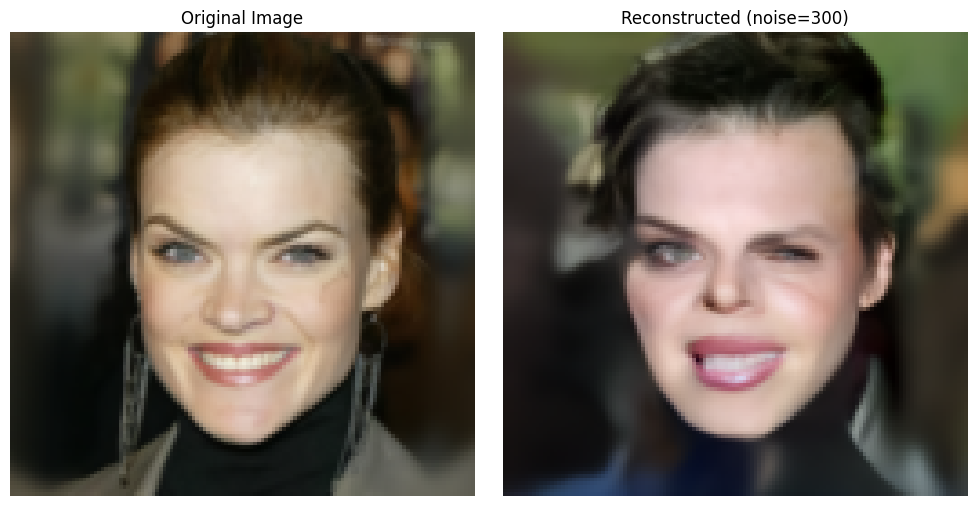

tensor([[[[0.3101, 0.3208, 0.3281,  ..., 0.3625, 0.3516, 0.3397],
          [0.3078, 0.3156, 0.3244,  ..., 0.3633, 0.3561, 0.3483],
          [0.3017, 0.3089, 0.3185,  ..., 0.3605, 0.3550, 0.3500],
          ...,
          [0.0934, 0.0946, 0.0914,  ..., 0.1916, 0.2063, 0.2171],
          [0.1025, 0.1033, 0.1023,  ..., 0.1917, 0.2056, 0.2179],
          [0.1153, 0.1178, 0.1168,  ..., 0.1899, 0.2044, 0.2162]],

         [[0.3148, 0.3248, 0.3370,  ..., 0.4528, 0.4384, 0.4278],
          [0.3020, 0.3127, 0.3253,  ..., 0.4530, 0.4443, 0.4396],
          [0.2888, 0.2988, 0.3117,  ..., 0.4528, 0.4454, 0.4430],
          ...,
          [0.0885, 0.0899, 0.0905,  ..., 0.2103, 0.2250, 0.2344],
          [0.1030, 0.1039, 0.1056,  ..., 0.2145, 0.2269, 0.2376],
          [0.1156, 0.1162, 0.1217,  ..., 0.2145, 0.2270, 0.2398]],

         [[0.1875, 0.1976, 0.2027,  ..., 0.2672, 0.2575, 0.2467],
          [0.1836, 0.1933, 0.2003,  ..., 0.2712, 0.2660, 0.2579],
          [0.1801, 0.1881, 0.1946,  ..., 0

In [56]:
MODEL_PATH = '/kaggle/working/best_model.pt'
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print('Model loaded!')
@torch.no_grad()
def generate_images(num_images=5):
    x = torch.randn(num_images, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)

    for t_val in tqdm(range(TIMESTEPS - 1, -1, -1), desc='Generating'):
        t_batch = torch.full((num_images,), t_val, device=device, dtype=torch.long)
        pred_noise = model(x, t_batch)

        alpha_t      = alphas[t_val].to(device)
        alpha_hat_t  = alphas_cumprod[t_val].to(device)
        alpha_hat_tm1 = alphas_cumprod_prev[t_val].to(device)

        # DDPM reverse step (correct formula)
        x0_pred = (x - torch.sqrt(1 - alpha_hat_t) * pred_noise) / torch.sqrt(alpha_hat_t)
        x0_pred = torch.clamp(x0_pred, -1, 1)

        noise = torch.randn_like(x) if t_val > 0 else torch.zeros_like(x)
        mean  = (torch.sqrt(alpha_hat_tm1) * (1 - alpha_t) / (1 - alpha_hat_t)) * x0_pred \
              + (torch.sqrt(alpha_t) * (1 - alpha_hat_tm1) / (1 - alpha_hat_t)) * x

        var = (1 - alpha_hat_tm1) / (1 - alpha_hat_t) * (1 - alpha_t)
        x   = mean + torch.sqrt(var) * noise

    imgs = torch.clamp((x + 1) / 2, 0, 1)

    fig, axes = plt.subplots(1, num_images, figsize=(num_images * 3, 3))
    for i, ax in enumerate(axes):
        ax.imshow(imgs[i].permute(1, 2, 0).cpu())
        ax.set_title(f'Generated {i+1}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    return imgs

@torch.no_grad()
def reconstruct_image(image_path, noise_level=500):
    transform = transforms.Compose([
        transforms.Resize(IMAGE_SIZE),
        transforms.CenterCrop(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

    orig = transform(Image.open(image_path).convert('RGB')).unsqueeze(0).to(device)

    noise = torch.randn_like(orig)
    sqrt_ahat  = torch.sqrt(alphas_cumprod[noise_level]).to(device)
    sqrt_1mahat = torch.sqrt(1 - alphas_cumprod[noise_level]).to(device)
    x = sqrt_ahat * orig + sqrt_1mahat * noise

    for t_val in tqdm(range(noise_level - 1, -1, -1), desc='Reconstructing'):
        t_batch = torch.full((1,), t_val, device=device, dtype=torch.long)
        pred_noise = model(x, t_batch)

        alpha_t       = alphas[t_val].to(device)
        alpha_hat_t   = alphas_cumprod[t_val].to(device)
        alpha_hat_tm1 = alphas_cumprod_prev[t_val].to(device)

        x0_pred = (x - torch.sqrt(1 - alpha_hat_t) * pred_noise) / torch.sqrt(alpha_hat_t)
        x0_pred = torch.clamp(x0_pred, -1, 1)

        noise_step = torch.randn_like(x) if t_val > 0 else torch.zeros_like(x)
        mean  = (torch.sqrt(alpha_hat_tm1) * (1 - alpha_t) / (1 - alpha_hat_t)) * x0_pred \
              + (torch.sqrt(alpha_t) * (1 - alpha_hat_tm1) / (1 - alpha_hat_t)) * x
        var = (1 - alpha_hat_tm1) / (1 - alpha_hat_t) * (1 - alpha_t)
        x   = mean + torch.sqrt(var) * noise_step

    result = torch.clamp((x + 1) / 2, 0, 1)
    orig_d  = torch.clamp((orig + 1) / 2, 0, 1)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(orig_d[0].permute(1, 2, 0).cpu())
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    axes[1].imshow(result[0].permute(1, 2, 0).cpu())
    axes[1].set_title(f'Reconstructed (noise={noise_level})')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()
    return result

generated = generate_images(num_images=5)

print (reconstruct_image("/kaggle/input/datasets/denislukovnikov/celebahq256-images-only/celebahq256_imgs/train/img_0.png", noise_level=300))

In [55]:
real_img = dataset[0].unsqueeze(0).to(device)   # (1, 3, 128, 128)
real_img = (real_img + 1) / 2

# PSNR
mse  = F.mse_loss(gen_single, real_img)
psnr = 20 * torch.log10(1.0 / torch.sqrt(mse))

# SSIM
i1 = gen_single[0].permute(1,2,0).cpu().numpy()
i2 = real_img[0].permute(1,2,0).cpu().numpy()
sim = ssim(i1, i2, data_range=1.0, channel_axis=2)

print(f'PSNR : {psnr:.2f} dB')
print(f'SSIM : {sim:.4f}')

PSNR : 11.11 dB
SSIM : 0.2239
